# Ethene grid generator

Use one source geometry as a reference to construct an ethene grid.

The grid spans C=C bond lengths from 1.1 to 3.0 Å in 0.1 Å steps and H-C-C-H dihedrals from 0.01 to 180.01° in 5° steps.

Then find the normal modes of ethene and generate one random displacement for each selected mode.

In [73]:
from pathlib import Path

import numpy as np
from ase import Atoms
from ase.io import write

SOURCE_XYZ = Path("../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_FINAL.xyz")
OUTPUT_XYZ = Path("../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_generated_bond_dihedral.xyz")
REFERENCE_CC_BOND_LENGTH = 1.336172  # Å; selects the source reference geometry.
REFERENCE_DIHEDRAL = 0.0  # degrees; selects the source reference geometry.
CC_BOND_LENGTHS = np.round(np.arange(1.1, 3.0 + 0.05, 0.1), 6)
DIHEDRAL_ANGLES = np.round(np.arange(0.01, 180.01 + 2.5, 5.0), 6)


def h_c_c_h_dihedral(positions):
    """Return the H(2)-C(0)-C(1)-H(3) dihedral in degrees."""
    a, b, c, d = positions[2], positions[0], positions[1], positions[3]
    bond0 = -(b - a)
    bond1 = c - b
    bond2 = d - c
    bond1 /= np.linalg.norm(bond1)
    v = bond0 - np.dot(bond0, bond1) * bond1
    w = bond2 - np.dot(bond2, bond1) * bond1
    return np.degrees(np.arctan2(np.dot(np.cross(bond1, v), w), np.dot(v, w)))


def read_raw_xyz_frames(path):
    """Read frames while retaining their original raw extended-XYZ text."""
    lines = path.read_text().splitlines(keepends=True)
    frames = []
    cursor = 0
    while cursor < len(lines):
        if not lines[cursor].strip():
            cursor += 1
            continue
        natoms = int(lines[cursor])
        stop = cursor + natoms + 2
        if stop > len(lines):
            raise ValueError(f"Incomplete frame starting at line {cursor + 1}")
        atom_lines = lines[cursor + 2 : stop]
        positions = np.array([[float(value) for value in line.split()[1:4]] for line in atom_lines])
        if positions.shape != (6, 3):
            raise ValueError(f"Expected six atoms, got {positions.shape[0]}")
        frames.append({"source_frame_index": len(frames), "raw": "".join(lines[cursor:stop]), "positions": positions})
        cursor = stop
    return frames


source_frames = read_raw_xyz_frames(SOURCE_XYZ)
for frame in source_frames:
    positions = frame["positions"]
    frame["bond"] = round(float(np.linalg.norm(positions[1] - positions[0])), 6)
    frame["dihedral"] = round(float(h_c_c_h_dihedral(positions)), 6)

reference_source_frame = min(
    source_frames,
    key=lambda frame: (frame["bond"] - REFERENCE_CC_BOND_LENGTH) ** 2
    + ((frame["dihedral"] - REFERENCE_DIHEDRAL + 180) % 360 - 180) ** 2,
)
if not np.isclose(reference_source_frame["bond"], REFERENCE_CC_BOND_LENGTH, atol=1e-6):
    raise ValueError("The requested C=C reference geometry is unavailable")
REFERENCE_POSITIONS = reference_source_frame["positions"].copy()
REFERENCE_SOURCE_FRAME_INDEX = reference_source_frame["source_frame_index"]

carbon_indices = (0, 1)
hydrogen_indices = (2, 3, 4, 5)
hydrogens_by_carbon = {
    carbon: tuple(
        hydrogen for hydrogen in hydrogen_indices
        if np.argmin([np.linalg.norm(REFERENCE_POSITIONS[hydrogen] - REFERENCE_POSITIONS[c]) for c in carbon_indices])
        == carbon
    )
    for carbon in carbon_indices
}
if 2 not in hydrogens_by_carbon[0] or 3 not in hydrogens_by_carbon[1]:
    raise ValueError("Unexpected ethene atom ordering in the reference geometry")

def wrapped_angle_difference(actual, target):
    """Return actual - target in the interval [-180, 180)."""
    return (actual - target + 180.0) % 360.0 - 180.0

def rotate_about_axis(positions, indices, origin, axis, angle_degrees):
    """Rotate selected positions using Rodrigues' rotation formula."""
    angle = np.radians(angle_degrees)
    vectors = positions[list(indices)] - origin
    positions[list(indices)] = (
        origin
        + vectors * np.cos(angle)
        + np.cross(axis, vectors) * np.sin(angle)
        + np.outer(np.dot(vectors, axis), axis) * (1.0 - np.cos(angle))
    )

reference_bond = float(np.linalg.norm(REFERENCE_POSITIONS[1] - REFERENCE_POSITIONS[0]))
reference_dihedral = float(h_c_c_h_dihedral(REFERENCE_POSITIONS))
cc_axis = (REFERENCE_POSITIONS[1] - REFERENCE_POSITIONS[0]) / reference_bond
moving_fragment = (1, *hydrogens_by_carbon[1])
trial_positions = REFERENCE_POSITIONS.copy()
rotate_about_axis(trial_positions, hydrogens_by_carbon[1], REFERENCE_POSITIONS[0], cc_axis, 1.0)
rotation_sign = np.sign(wrapped_angle_difference(h_c_c_h_dihedral(trial_positions), reference_dihedral))
if rotation_sign == 0:
    raise ValueError("Could not calibrate the dihedral rotation direction")

bond_coordinates = [float(value) for value in CC_BOND_LENGTHS]
dihedral_coordinates = [float(value) for value in DIHEDRAL_ANGLES]
selected_bonds = bond_coordinates
selected_dihedrals = dihedral_coordinates
selected_keys = [(bond, dihedral) for bond in selected_bonds for dihedral in selected_dihedrals]
frames = []
frame_by_coordinate = {}
generated_atoms = []

for source_frame_index, (bond, dihedral) in enumerate(selected_keys):
    positions = REFERENCE_POSITIONS.copy()
    positions[list(moving_fragment)] += (bond - reference_bond) * cc_axis
    rotation_angle = wrapped_angle_difference(dihedral, reference_dihedral) / rotation_sign
    rotate_about_axis(positions, hydrogens_by_carbon[1], positions[0], cc_axis, rotation_angle)

    measured_bond = float(np.linalg.norm(positions[1] - positions[0]))
    measured_dihedral = float(h_c_c_h_dihedral(positions))
    if not np.isclose(measured_bond, bond, atol=1e-8):
        raise AssertionError(f"C=C bond mismatch: expected {bond}, got {measured_bond}")
    if abs(wrapped_angle_difference(measured_dihedral, dihedral)) > 1e-8:
        raise AssertionError(f"Dihedral mismatch: expected {dihedral}, got {measured_dihedral}")

    frame = {
        "source_frame_index": source_frame_index,
        "reference_source_frame_index": REFERENCE_SOURCE_FRAME_INDEX,
        "positions": positions,
        "bond": bond,
        "dihedral": dihedral,
    }
    frames.append(frame)
    frame_by_coordinate[(bond, dihedral)] = frame
    atoms = Atoms(symbols=["C", "C", "H", "H", "H", "H"], positions=positions, pbc=False)
    atoms.info = {
        "source_frame_index": source_frame_index,
        "reference_source_frame_index": REFERENCE_SOURCE_FRAME_INDEX,
        "grid_cc_bond_angstrom": bond,
        "grid_dihedral_deg": dihedral,
    }
    generated_atoms.append(atoms)

expected_grid_size = len(CC_BOND_LENGTHS) * len(DIHEDRAL_ANGLES)
if len(selected_keys) != expected_grid_size or expected_grid_size != 20 * 37:
    raise AssertionError(f"Expected a 20 x 37 grid, got {len(selected_keys)} geometries")
write(OUTPUT_XYZ, generated_atoms, format="extxyz")
print(f"Wrote {len(generated_atoms)} generated geometries to {OUTPUT_XYZ.resolve()}")
print(f"Grid shape: {len(CC_BOND_LENGTHS)} bond coordinates x {len(DIHEDRAL_ANGLES)} dihedrals")


Wrote 740 generated geometries to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_generated_bond_dihedral.xyz
Grid shape: 20 bond coordinates x 37 dihedrals


In [53]:
from ase import Atoms
from xtb.ase.calculator import XTB
from wfl.configset import ConfigSet, OutputSpec
from wfl.generate import normal_modes as nm

REFERENCE_NM_XYZ = Path("ethene_reference_normal_modes.xyz")
reference_atoms = Atoms(
    symbols=["C", "C", "H", "H", "H", "H"],
    positions=REFERENCE_POSITIONS,
    pbc=False,
)
configset = ConfigSet([reference_atoms])
outputspec = OutputSpec(REFERENCE_NM_XYZ, overwrite=True)

calc = (XTB, [], {"method": "GFN2-xTB"})
prop_prefix = "xtb2_"

nm.generate_normal_modes_parallel_hessian(inputs=configset,
                                          outputs=outputspec,
                                          calculator=calc,
                                          prop_prefix=prop_prefix)

print(
    f"Wrote normal modes for C-C = {reference_bond:.6f} Å, "
    f"dihedral = {reference_dihedral:.1f}° to {REFERENCE_NM_XYZ.resolve()}"
)

Wrote normal modes for C-C = 1.336172 Å, dihedral = 0.0° to /home/lim_yt/X-MACE-sampling/notebooks/ethene_reference_normal_modes.xyz


In [54]:
from ase.io import read
from wfl.generate import normal_modes as nm

at = read(REFERENCE_NM_XYZ)
ethene_nm = nm.NormalModes(at, "xtb2_")

# Writes trajectories of the selected normal modes to file.
ethene_nm.view()

# prints frequencies
ethene_nm.summary()

---------------------

  #    meV     cm^-1

---------------------

  0   18.9 i   152.1 i
  1    0.0 i     0.0 i
  2    0.0 i     0.0 i
  3   48.1     387.7  
  4   56.0     451.8  
  5   60.2     485.5  
  6  100.5     810.4  
  7  107.0     863.2  
  8  117.7     949.4  
  9  125.7    1013.6  
 10  131.6    1061.2  
 11  170.6    1375.9  
 12  175.4    1414.4  
 13  201.8    1627.4  
 14  376.7    3038.2  
 15  377.0    3040.5  
 16  381.7    3078.9  
 17  382.6    3086.2  
---------------------



In [55]:
from itertools import product

from ase import Atoms
from ase.io import read, write

AUGMENTED_OUTPUT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_extended_further.xyz" 
)
SELECTED_MODES = (14, 15, 16, 17)
NORMAL_COORDINATES = (-0.15, 0.15)  # Å multipliers of normalized mode vectors

normal_mode_atoms = read(REFERENCE_NM_XYZ)
ethene_nm = nm.NormalModes(normal_mode_atoms, prop_prefix)
if max(SELECTED_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"Selected modes {SELECTED_MODES} are unavailable")
mode_vectors = {mode: ethene_nm.modes[mode] for mode in SELECTED_MODES}

augmented_atoms = []
for base_key in selected_keys:
    base_frame = frame_by_coordinate[base_key]
    for mode_coordinates in product(NORMAL_COORDINATES, repeat=len(SELECTED_MODES)):
        displacement = sum(
            coordinate * mode_vectors[mode]
            for mode, coordinate in zip(SELECTED_MODES, mode_coordinates)
        )
        atoms = Atoms(
            symbols=["C", "C", "H", "H", "H", "H"],
            positions=base_frame["positions"] + displacement,
            pbc=False,
        )
        atoms.info = {
            "source_frame_index": base_frame["source_frame_index"],
            "grid_cc_bond_angstrom": base_key[0],
            "grid_dihedral_deg": base_key[1],
            **{
                f"mode_{mode}_coordinate_angstrom": coordinate
                for mode, coordinate in zip(SELECTED_MODES, mode_coordinates)
            },
        }
        if not any(mode_coordinates) and not np.array_equal(atoms.positions, base_frame["positions"]):
            raise AssertionError("Zero normal-mode coordinates must reproduce the base geometry")
        augmented_atoms.append(atoms)

expected_count = len(selected_keys) * len(NORMAL_COORDINATES) ** len(SELECTED_MODES)
if len(augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} geometries, got {len(augmented_atoms)}")

write(AUGMENTED_OUTPUT_XYZ, augmented_atoms, format="extxyz")
print(f"Wrote {len(augmented_atoms)} geometry-only 4D grid points to {AUGMENTED_OUTPUT_XYZ.resolve()}")


Wrote 11840 geometry-only 4D grid points to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_extended_further.xyz


# Better calculator

Ethene has 12 vibration modes; subtract the CC stretch and HCH twist modes because they are already accounted for in the grid.

Input the desired ranges for CH bond length,  CCH bond angle, HCH bond angle, pyramidalisation.
For the corresponding vibration modes, calculators will return the q ranges needed.

Put the q ranges into the grid generator.
Each geometry will be displaced by each vibration mode by a random magnitude within the q range,
creating 10 augmented geometries per initial geometry.

In [74]:
# C-H displacement-range calculator.
CH_MODES = (14, 15, 16, 17)
CH_BOND_LENGTH_RANGE = (0.82, 2.00)  # Å

if not CH_MODES or len(set(CH_MODES)) != len(CH_MODES):
    raise ValueError("CH_MODES must contain unique mode indices")
CH_BOND_LENGTH_RANGE = tuple(float(value) for value in CH_BOND_LENGTH_RANGE)
if (len(CH_BOND_LENGTH_RANGE) != 2 or not np.all(np.isfinite(CH_BOND_LENGTH_RANGE))
        or CH_BOND_LENGTH_RANGE[0] <= 0 or CH_BOND_LENGTH_RANGE[0] >= CH_BOND_LENGTH_RANGE[1]):
    raise ValueError("CH_BOND_LENGTH_RANGE must be an ordered, positive (minimum, maximum) pair")

normal_mode_atoms = read(REFERENCE_NM_XYZ)
ethene_nm = nm.NormalModes(normal_mode_atoms, prop_prefix)
if min(CH_MODES) < 0 or max(CH_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"C-H modes {CH_MODES} are unavailable")
mode_vectors = {mode: ethene_nm.modes[mode] for mode in CH_MODES}

symbols = np.asarray(normal_mode_atoms.get_chemical_symbols())
carbon_indices = np.flatnonzero(symbols == "C")
hydrogen_indices = np.flatnonzero(symbols == "H")
if len(carbon_indices) != 2 or len(hydrogen_indices) != 4:
    raise ValueError("Expected ethene to contain two carbons and four hydrogens")

# Associate each H with its closest C in the reference geometry.
CH_BONDS = tuple(
    (int(carbon_indices[np.argmin(np.linalg.norm(
        normal_mode_atoms.positions[hydrogen] - normal_mode_atoms.positions[carbon_indices],
        axis=1,
    ))]), int(hydrogen))
    for hydrogen in hydrogen_indices
)
if any(
    np.linalg.norm(normal_mode_atoms.positions[hydrogen] - normal_mode_atoms.positions[carbon]) >= 1.5
    for carbon, hydrogen in CH_BONDS
):
    raise ValueError("Could not identify four C-H bonds from the reference geometry")

for base_key in selected_keys:
    positions = frame_by_coordinate[base_key]["positions"]
    for carbon, hydrogen in CH_BONDS:
        distances_to_carbons = np.linalg.norm(
            positions[hydrogen] - positions[carbon_indices], axis=1
        )
        if (
            carbon != carbon_indices[np.argmin(distances_to_carbons)]
            or np.linalg.norm(positions[hydrogen] - positions[carbon]) >= 1.5
        ):
            raise ValueError(f"C-H bonding assignment changed at grid coordinate {base_key}")

def ch_boundary_roots(positions, mode_vector, bond, target_length):
    """Return all real q values where one C-H bond reaches target_length."""
    carbon, hydrogen = bond
    relative_position = positions[hydrogen] - positions[carbon]
    relative_mode = mode_vector[hydrogen] - mode_vector[carbon]
    a = np.dot(relative_mode, relative_mode)
    b = 2 * np.dot(relative_position, relative_mode)
    c = np.dot(relative_position, relative_position) - target_length**2
    if a <= np.finfo(float).eps:
        return ()
    discriminant = b**2 - 4 * a * c
    if discriminant < 0:
        return ()
    roots = np.sort(((-b - np.sqrt(discriminant)) / (2 * a),
                     (-b + np.sqrt(discriminant)) / (2 * a)))
    return roots

def nearest_q_exits(mode, coordinates, value_at_q, roots_at_boundary, value_range):
    """Find the nearest valid-range exit on each side of q=0 across the grid."""
    lower, upper = value_range
    negative_candidates, positive_candidates = [], []
    for base_key in selected_keys:
        positions = frame_by_coordinate[base_key]["positions"]
        for coordinate in coordinates:
            initial_value = value_at_q(positions, mode_vectors[mode], coordinate, 0.0)
            if not lower - 1e-8 <= initial_value <= upper + 1e-8:
                raise ValueError(
                    f"Mode {mode}: unperturbed {coordinate} value {initial_value:.6f} is outside "
                    f"the requested range {value_range} at {base_key}"
                )
            for boundary in value_range:
                for root in roots_at_boundary(positions, mode_vectors[mode], coordinate, boundary):
                    candidate = (float(root), base_key, coordinate, boundary)
                    if root < -1e-10:
                        negative_candidates.append(candidate)
                    elif root > 1e-10:
                        positive_candidates.append(candidate)
    if not negative_candidates or not positive_candidates:
        raise ValueError(f"Mode {mode} has no finite q range for {value_range}")
    return (
        max(negative_candidates, key=lambda item: item[0]),
        min(positive_candidates, key=lambda item: item[0]),
    )

def ch_distance(positions, mode_vector, bond, q):
    carbon, hydrogen = bond
    displaced = positions + q * mode_vector
    return float(np.linalg.norm(displaced[hydrogen] - displaced[carbon]))

CH_MODE_RANGES_BY_MODE = {}
for mode in CH_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, CH_BONDS, ch_distance, ch_boundary_roots, CH_BOND_LENGTH_RANGE
    )
    CH_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, bond, boundary = exit_candidate
        value = ch_distance(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], bond, q)
        if not np.isclose(value, boundary, atol=1e-8):
            raise AssertionError("C-H target root did not reproduce the target length")
    print(
        f"C-H mode {mode}: q range {CH_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: {negative_exit[2]} at {negative_exit[1]} reaches {negative_exit[3]} Å; "
        f"positive: {positive_exit[2]} at {positive_exit[1]} reaches {positive_exit[3]} Å"
    )



C-H mode 14: q range (-1.5518699586668623, 0.45245498437241227); negative: (0, 2) at (1.1, 0.01) reaches 2.0 Å; positive: (0, 2) at (1.1, 0.01) reaches 0.82 Å
C-H mode 15: q range (-0.4594993584330527, 0.4594993595357959); negative: (1, 3) at (1.1, 0.01) reaches 0.82 Å; positive: (0, 2) at (1.1, 0.01) reaches 0.82 Å
C-H mode 16: q range (-0.3733166095056574, 0.3733166095056574); negative: (0, 2) at (1.1, 0.01) reaches 0.82 Å; positive: (0, 5) at (1.1, 0.01) reaches 0.82 Å
C-H mode 17: q range (-0.37065449355284985, 0.37065449355284985); negative: (0, 2) at (1.1, 0.01) reaches 0.82 Å; positive: (0, 5) at (1.1, 0.01) reaches 0.82 Å


In [75]:
# C-C-H angle displacement-range calculator.
CCH_MODES = (7, 9)
CCH_ANGLE_RANGE = (17.3, 178.1)  # degrees

if not CCH_MODES or len(set(CCH_MODES)) != len(CCH_MODES):
    raise ValueError("CCH_MODES must contain unique mode indices")
if set(CH_MODES) & set(CCH_MODES):
    raise ValueError("CH_MODES and CCH_MODES must not overlap")
CCH_ANGLE_RANGE = tuple(float(value) for value in CCH_ANGLE_RANGE)
if (len(CCH_ANGLE_RANGE) != 2 or not np.all(np.isfinite(CCH_ANGLE_RANGE))
        or not 0 < CCH_ANGLE_RANGE[0] < CCH_ANGLE_RANGE[1] < 180):
    raise ValueError("CCH_ANGLE_RANGE must be an ordered pair strictly between 0 and 180 degrees")
if min(CCH_MODES) < 0 or max(CCH_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"C-C-H modes {CCH_MODES} are unavailable")
mode_vectors.update({mode: ethene_nm.modes[mode] for mode in CCH_MODES})

CCH_ANGLES = tuple(
    (next(other for other in carbon_indices if other != carbon), carbon, hydrogen)
    for carbon, hydrogen in CH_BONDS
)

def cch_angle(positions, mode_vector, angle_atoms, q):
    outer_carbon, central_carbon, hydrogen = angle_atoms
    displaced = positions + q * mode_vector
    cc_vector = displaced[outer_carbon] - displaced[central_carbon]
    ch_vector = displaced[hydrogen] - displaced[central_carbon]
    cosine = np.dot(cc_vector, ch_vector) / (np.linalg.norm(cc_vector) * np.linalg.norm(ch_vector))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))

def cch_boundary_roots(positions, mode_vector, angle_atoms, target_angle):
    """Solve the squared C-C-H angle equation and retain valid real roots."""
    outer_carbon, central_carbon, hydrogen = angle_atoms
    cc0 = positions[outer_carbon] - positions[central_carbon]
    ch0 = positions[hydrogen] - positions[central_carbon]
    cc1 = mode_vector[outer_carbon] - mode_vector[central_carbon]
    ch1 = mode_vector[hydrogen] - mode_vector[central_carbon]
    dot = np.array([np.dot(cc0, ch0), np.dot(cc0, ch1) + np.dot(cc1, ch0), np.dot(cc1, ch1)])
    cc_norm_sq = np.array([np.dot(cc0, cc0), 2 * np.dot(cc0, cc1), np.dot(cc1, cc1)])
    ch_norm_sq = np.array([np.dot(ch0, ch0), 2 * np.dot(ch0, ch1), np.dot(ch1, ch1)])
    cosine_squared = np.cos(np.radians(target_angle)) ** 2
    coefficients = np.polynomial.polynomial.polyadd(
        np.polynomial.polynomial.polymul(dot, dot),
        -cosine_squared * np.polynomial.polynomial.polymul(cc_norm_sq, ch_norm_sq),
    )
    coefficients = np.trim_zeros(coefficients, trim="b")
    if len(coefficients) <= 1:
        return ()
    roots = np.roots(coefficients[::-1])
    real_roots = sorted(root.real for root in roots if abs(root.imag) < 1e-8)
    return tuple(
        root for index, root in enumerate(real_roots)
        if (index == 0 or not np.isclose(root, real_roots[index - 1], atol=1e-8))
        and np.isclose(cch_angle(positions, mode_vector, angle_atoms, root), target_angle, atol=1e-6)
    )

CCH_MODE_RANGES_BY_MODE = {}
for mode in CCH_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, CCH_ANGLES, cch_angle, cch_boundary_roots, CCH_ANGLE_RANGE
    )
    CCH_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, angle_atoms, boundary = exit_candidate
        value = cch_angle(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], angle_atoms, q)
        if not np.isclose(value, boundary, atol=1e-6):
            raise AssertionError("C-C-H target root did not reproduce the target angle")
    print(
        f"C-C-H mode {mode}: q range {CCH_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: {negative_exit[2]} at {negative_exit[1]} reaches {negative_exit[3]}°; "
        f"positive: {positive_exit[2]} at {positive_exit[1]} reaches {positive_exit[3]}°"
    )


C-C-H mode 7: q range (-2.127407875161393, 2.127407875161393); negative: (np.int64(0), 1, 4) at (2.1, 180.01) reaches 17.3°; positive: (np.int64(0), 1, 3) at (2.1, 180.01) reaches 17.3°
C-C-H mode 9: q range (-0.7680550719762049, 0.7680550719762049); negative: (np.int64(1), 0, 5) at (1.1, 0.01) reaches 178.1°; positive: (np.int64(1), 0, 2) at (1.1, 0.01) reaches 178.1°


In [76]:
# Carbon pyramidalisation displacement-range calculator.
PYRAMIDALISATION_MODES = (6, 8)
PYRAMIDALISATION_RANGE = (0.0, 1.17)  # Å

if not PYRAMIDALISATION_MODES or len(set(PYRAMIDALISATION_MODES)) != len(PYRAMIDALISATION_MODES):
    raise ValueError("PYRAMIDALISATION_MODES must contain unique mode indices")
if set(PYRAMIDALISATION_MODES) & (set(CH_MODES) | set(CCH_MODES)):
    raise ValueError("Pyramidalisation modes overlap another calculator group")
PYRAMIDALISATION_RANGE = tuple(float(value) for value in PYRAMIDALISATION_RANGE)
if (len(PYRAMIDALISATION_RANGE) != 2 or not np.all(np.isfinite(PYRAMIDALISATION_RANGE))
        or PYRAMIDALISATION_RANGE[0] < 0 or PYRAMIDALISATION_RANGE[0] >= PYRAMIDALISATION_RANGE[1]):
    raise ValueError("PYRAMIDALISATION_RANGE must be an ordered, non-negative (minimum, maximum) pair")
if min(PYRAMIDALISATION_MODES) < 0 or max(PYRAMIDALISATION_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"Pyramidalisation modes {PYRAMIDALISATION_MODES} are unavailable")
mode_vectors.update({mode: ethene_nm.modes[mode] for mode in PYRAMIDALISATION_MODES})

hydrogens_by_carbon = {
    carbon: tuple(hydrogen for bonded_carbon, hydrogen in CH_BONDS if bonded_carbon == carbon)
    for carbon in carbon_indices
}
if any(len(hydrogens) != 2 for hydrogens in hydrogens_by_carbon.values()):
    raise ValueError("Expected each carbon to have two bonded hydrogens")
PYRAMIDALISATION_SITES = tuple(
    (carbon, next(other for other in carbon_indices if other != carbon), *hydrogens_by_carbon[carbon])
    for carbon in carbon_indices
)

def pyramidalisation_distance(positions, mode_vector, site, q):
    carbon, plane_atom0, plane_atom1, plane_atom2 = site
    displaced = positions + q * mode_vector
    normal = np.cross(displaced[plane_atom1] - displaced[plane_atom0],
                      displaced[plane_atom2] - displaced[plane_atom0])
    normal_norm = np.linalg.norm(normal)
    if normal_norm <= np.finfo(float).eps:
        raise ValueError(f"Degenerate bonded-atom plane for carbon {carbon}")
    return float(abs(np.dot(displaced[carbon] - displaced[plane_atom0], normal)) / normal_norm)

def pyramidalisation_boundary_roots(positions, mode_vector, site, target_distance):
    """Solve the squared carbon-to-bonded-plane distance equation."""
    carbon, plane_atom0, plane_atom1, plane_atom2 = site
    a0 = positions[plane_atom1] - positions[plane_atom0]
    b0 = positions[plane_atom2] - positions[plane_atom0]
    a1 = mode_vector[plane_atom1] - mode_vector[plane_atom0]
    b1 = mode_vector[plane_atom2] - mode_vector[plane_atom0]
    normal = (np.cross(a0, b0), np.cross(a0, b1) + np.cross(a1, b0), np.cross(a1, b1))
    point0 = positions[carbon] - positions[plane_atom0]
    point1 = mode_vector[carbon] - mode_vector[plane_atom0]
    numerator = np.array([
        np.dot(point0, normal[0]),
        np.dot(point0, normal[1]) + np.dot(point1, normal[0]),
        np.dot(point0, normal[2]) + np.dot(point1, normal[1]),
        np.dot(point1, normal[2]),
    ])
    normal_norm_sq = np.array([
        np.dot(normal[0], normal[0]),
        2 * np.dot(normal[0], normal[1]),
        2 * np.dot(normal[0], normal[2]) + np.dot(normal[1], normal[1]),
        2 * np.dot(normal[1], normal[2]),
        np.dot(normal[2], normal[2]),
    ])
    coefficients = np.polynomial.polynomial.polyadd(
        np.polynomial.polynomial.polymul(numerator, numerator),
        -target_distance**2 * normal_norm_sq,
    )
    coefficients = np.trim_zeros(coefficients, trim="b")
    if len(coefficients) <= 1:
        return ()
    roots = np.roots(coefficients[::-1])
    real_roots = sorted(root.real for root in roots if abs(root.imag) < 1e-8)
    return tuple(
        root for index, root in enumerate(real_roots)
        if (index == 0 or not np.isclose(root, real_roots[index - 1], atol=1e-8))
        and np.isclose(pyramidalisation_distance(positions, mode_vector, site, root), target_distance, atol=1e-7)
    )

PYRAMIDALISATION_MODE_RANGES_BY_MODE = {}
for mode in PYRAMIDALISATION_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, PYRAMIDALISATION_SITES, pyramidalisation_distance,
        pyramidalisation_boundary_roots, PYRAMIDALISATION_RANGE,
    )
    PYRAMIDALISATION_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, site, boundary = exit_candidate
        value = pyramidalisation_distance(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], site, q)
        if not np.isclose(value, boundary, atol=1e-7):
            raise AssertionError("Pyramidalisation target root did not reproduce the target distance")
    print(
        f"Pyramidalisation mode {mode}: q range {PYRAMIDALISATION_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: C{negative_exit[2][0]} at {negative_exit[1]} reaches {negative_exit[3]} Å; "
        f"positive: C{positive_exit[2][0]} at {positive_exit[1]} reaches {positive_exit[3]} Å"
    )


Pyramidalisation mode 6: q range (-1.5979242705674315, 1.5979242705674312); negative: C0 at (3.0, 0.01) reaches 1.17 Å; positive: C0 at (3.0, 0.01) reaches 1.17 Å
Pyramidalisation mode 8: q range (-1.4611626280821355, 1.4611626280821355); negative: C0 at (3.0, 0.01) reaches 1.17 Å; positive: C0 at (3.0, 0.01) reaches 1.17 Å


In [77]:
# H-C-H angle displacement-range calculator.
HCH_MODES = (11, 12)
HCH_ANGLE_RANGE = (21.1, 178.8)  # degrees

if not HCH_MODES or len(set(HCH_MODES)) != len(HCH_MODES):
    raise ValueError("HCH_MODES must contain unique mode indices")
if set(HCH_MODES) & (set(CH_MODES) | set(CCH_MODES) | set(PYRAMIDALISATION_MODES)):
    raise ValueError("H-C-H modes overlap another calculator group")
HCH_ANGLE_RANGE = tuple(float(value) for value in HCH_ANGLE_RANGE)
if (len(HCH_ANGLE_RANGE) != 2 or not np.all(np.isfinite(HCH_ANGLE_RANGE))
        or not 0 < HCH_ANGLE_RANGE[0] < HCH_ANGLE_RANGE[1] < 180):
    raise ValueError("HCH_ANGLE_RANGE must be an ordered pair strictly between 0 and 180 degrees")
if min(HCH_MODES) < 0 or max(HCH_MODES) >= ethene_nm.num_nm:
    raise ValueError(f"H-C-H modes {HCH_MODES} are unavailable")
mode_vectors.update({mode: ethene_nm.modes[mode] for mode in HCH_MODES})

HCH_ANGLES = tuple(
    (hydrogens[0], carbon, hydrogens[1])
    for carbon, hydrogens in hydrogens_by_carbon.items()
)
HCH_MODE_RANGES_BY_MODE = {}
for mode in HCH_MODES:
    negative_exit, positive_exit = nearest_q_exits(
        mode, HCH_ANGLES, cch_angle, cch_boundary_roots, HCH_ANGLE_RANGE
    )
    HCH_MODE_RANGES_BY_MODE[mode] = (negative_exit[0], positive_exit[0])
    for exit_candidate in (negative_exit, positive_exit):
        q, base_key, angle_atoms, boundary = exit_candidate
        value = cch_angle(frame_by_coordinate[base_key]["positions"], mode_vectors[mode], angle_atoms, q)
        if not np.isclose(value, boundary, atol=1e-6):
            raise AssertionError("H-C-H target root did not reproduce the target angle")
    print(
        f"H-C-H mode {mode}: q range {HCH_MODE_RANGES_BY_MODE[mode]}; "
        f"negative: {negative_exit[2]} at {negative_exit[1]} reaches {negative_exit[3]}°; "
        f"positive: {positive_exit[2]} at {positive_exit[1]} reaches {positive_exit[3]}°"
    )


H-C-H mode 11: q range (-3.2780215478556025, 3.4760786503061776); negative: (2, np.int64(0), 5) at (1.1, 0.01) reaches 178.8°; positive: (2, np.int64(0), 5) at (1.1, 0.01) reaches 21.1°
H-C-H mode 12: q range (-0.8390439855814724, 0.8390439856259185); negative: (2, np.int64(0), 5) at (1.1, 0.01) reaches 178.8°; positive: (3, np.int64(1), 4) at (1.7, 0.01) reaches 178.8°


In [60]:
# Generate random single-mode augmentations using all 4 calculator outputs.
from ase import Atoms
from ase.io import write

RANDOM_SEED = 42  # Controls random displacement magnitudes.
MAX_SINGLE_MODE_ATTEMPTS = 10_000
AUGMENTED_RANDOM_OUTPUT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_augment_by_vibration.xyz"
)

DISPLACEMENT_RANGES_BY_MODE = {
    **CCH_MODE_RANGES_BY_MODE,
    **PYRAMIDALISATION_MODE_RANGES_BY_MODE,
    **HCH_MODE_RANGES_BY_MODE,
    **CH_MODE_RANGES_BY_MODE,
}
SELECTED_MODES = tuple(DISPLACEMENT_RANGES_BY_MODE)
if len(SELECTED_MODES) != (
    len(CH_MODES) + len(CCH_MODES) + len(PYRAMIDALISATION_MODES) + len(HCH_MODES)
):
    raise ValueError("Calculator mode groups overlap")
if len(SELECTED_MODES) != 10:
    raise ValueError(f"Expected 10 applicable vibration modes, got {len(SELECTED_MODES)}")
for mode, displacement_range in DISPLACEMENT_RANGES_BY_MODE.items():
    if (len(displacement_range) != 2 or not np.all(np.isfinite(displacement_range))
            or displacement_range[0] >= displacement_range[1]):
        raise ValueError(f"Mode {mode} has no finite ordered calculator-derived q range")
AUGMENTATIONS_PER_GEOMETRY = len(SELECTED_MODES)
C1_FRAGMENT = (1, *(hydrogen for carbon, hydrogen in CH_BONDS if carbon == 1))
if len(C1_FRAGMENT) != 3:
    raise ValueError("Expected C1 and its two bonded hydrogens in C1_FRAGMENT")

SINGLE_MODE_ZERO_VECTOR = np.zeros_like(next(iter(mode_vectors.values())))

def single_mode_geometry_is_in_range(positions):
    ch_lengths = [ch_distance(positions, SINGLE_MODE_ZERO_VECTOR, bond, 0.0) for bond in CH_BONDS]
    cch_angles = [cch_angle(positions, SINGLE_MODE_ZERO_VECTOR, angle_atoms, 0.0) for angle_atoms in CCH_ANGLES]
    hch_angles = [cch_angle(positions, SINGLE_MODE_ZERO_VECTOR, angle_atoms, 0.0) for angle_atoms in HCH_ANGLES]
    pyramidalisation_distances = [
        pyramidalisation_distance(positions, SINGLE_MODE_ZERO_VECTOR, site, 0.0)
        for site in PYRAMIDALISATION_SITES
    ]
    return (
        all(CH_BOND_LENGTH_RANGE[0] <= value <= CH_BOND_LENGTH_RANGE[1] for value in ch_lengths)
        and all(CCH_ANGLE_RANGE[0] <= value <= CCH_ANGLE_RANGE[1] for value in cch_angles)
        and all(HCH_ANGLE_RANGE[0] <= value <= HCH_ANGLE_RANGE[1] for value in hch_angles)
        and all(PYRAMIDALISATION_RANGE[0] <= value <= PYRAMIDALISATION_RANGE[1]
                for value in pyramidalisation_distances)
    )

rng = np.random.default_rng(RANDOM_SEED)
augmented_atoms = []
for base_key in selected_keys:
    base_frame = frame_by_coordinate[base_key]
    for augmentation_index, mode in enumerate(SELECTED_MODES):
        configured_range = DISPLACEMENT_RANGES_BY_MODE[mode]
        for sample_attempt in range(1, MAX_SINGLE_MODE_ATTEMPTS + 1):
            displacement_coordinate = rng.uniform(*configured_range)
            positions = base_frame["positions"] + displacement_coordinate * mode_vectors[mode]
            unprojected_cc_vector = positions[1] - positions[0]
            unprojected_cc_bond = float(np.linalg.norm(unprojected_cc_vector))
            if unprojected_cc_bond <= np.finfo(float).eps:
                continue
            cc_correction_vector = (
                (base_key[0] - unprojected_cc_bond) * unprojected_cc_vector / unprojected_cc_bond
            )
            positions[list(C1_FRAGMENT)] += cc_correction_vector
            projected_cc_bond = float(np.linalg.norm(positions[1] - positions[0]))
            if (
                np.isclose(projected_cc_bond, base_key[0], atol=1e-10)
                and single_mode_geometry_is_in_range(positions)
            ):
                break
        else:
            raise RuntimeError(
                f"Could not generate an accepted single-mode augmentation for base geometry {base_key}, "
                f"mode {mode} after {MAX_SINGLE_MODE_ATTEMPTS} attempts"
            )
        atoms = Atoms(
            symbols=["C", "C", "H", "H", "H", "H"],
            positions=positions,
            pbc=False,
        )
        atoms.info = {
            "source_frame_index": base_frame["source_frame_index"],
            "grid_cc_bond_angstrom": base_key[0],
            "grid_dihedral_deg": base_key[1],
            "augmentation_index": augmentation_index,
            "selected_mode": mode,
            "single_mode_sample_attempt": sample_attempt,
            "mode_displacement_angstrom": displacement_coordinate,
            "unprojected_cc_bond_angstrom": unprojected_cc_bond,
            "projected_cc_bond_angstrom": projected_cc_bond,
            "cc_projection_translation_angstrom": float(np.linalg.norm(cc_correction_vector)),
            "configured_mode_q_min_angstrom": configured_range[0],
            "configured_mode_q_max_angstrom": configured_range[1],
            "ch_bond_length_min_angstrom": CH_BOND_LENGTH_RANGE[0],
            "ch_bond_length_max_angstrom": CH_BOND_LENGTH_RANGE[1],
            "cch_angle_min_degrees": CCH_ANGLE_RANGE[0],
            "cch_angle_max_degrees": CCH_ANGLE_RANGE[1],
            "pyramidalisation_min_angstrom": PYRAMIDALISATION_RANGE[0],
            "pyramidalisation_max_angstrom": PYRAMIDALISATION_RANGE[1],
            "hch_angle_min_degrees": HCH_ANGLE_RANGE[0],
            "hch_angle_max_degrees": HCH_ANGLE_RANGE[1],
        }
        augmented_atoms.append(atoms)

expected_count = len(selected_keys) * AUGMENTATIONS_PER_GEOMETRY
if len(augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} geometries, got {len(augmented_atoms)}")

write(AUGMENTED_RANDOM_OUTPUT_XYZ, augmented_atoms, format="extxyz")
print(
    f"Wrote {len(augmented_atoms)} random single-mode augmentations "
    f"({AUGMENTATIONS_PER_GEOMETRY} per base geometry) to "
    f"{AUGMENTED_RANDOM_OUTPUT_XYZ.resolve()}"
)


Wrote 7400 random single-mode augmentations (10 per base geometry) to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_augment_by_vibration.xyz


In [61]:
# Generate augmentations by applying one random displacement from every mode at once.
# Set the q ranges manually below; values are in Å along the normalized mode vectors.
from ase import Atoms
from ase.io import write

COMBINED_AUGMENTATIONS_PER_GEOMETRY = 10
COMBINED_RANDOM_SEED = 42
MAX_COMBINED_ATTEMPTS = 10_000
COMBINED_AUGMENTED_OUTPUT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations.xyz"
)

# Edit these (minimum, maximum) q values to control the displacement of each mode.
# The initial values reproduce the calculator-derived ranges previously used here.
COMBINED_DISPLACEMENT_RANGES_BY_MODE = {
    6: (-0.35, 0.35),  # pyramidalisation
    7: (-0.90, 0.90),  # C-C-H
    8: (-0.32, 0.32),  # pyramidalisation
    9: (-0.30, 0.30),  # C-C-H
    11: (-0.90, 0.90), # H-C-H
    12: (-0.25, 0.25), # H-C-H
    14: (-0.15, 0.15), # C-H
    15: (-0.12, 0.12), # C-H
    16: (-0.10, 0.10), # C-H
    17: (-0.10, 0.10), # C-H
}
COMBINED_MODES = tuple(COMBINED_DISPLACEMENT_RANGES_BY_MODE)
if len(COMBINED_MODES) != 10:
    raise ValueError(f"Expected 10 applicable vibration modes, got {len(COMBINED_MODES)}")
if COMBINED_AUGMENTATIONS_PER_GEOMETRY < 1 or MAX_COMBINED_ATTEMPTS < 1:
    raise ValueError("Combined augmentation and attempt counts must be at least 1")
for mode, displacement_range in COMBINED_DISPLACEMENT_RANGES_BY_MODE.items():
    if (len(displacement_range) != 2 or not np.all(np.isfinite(displacement_range))
            or displacement_range[0] >= displacement_range[1]):
        raise ValueError(f"Mode {mode} has no finite ordered manual q range")

C1_COMBINED_FRAGMENT = (1, *(hydrogen for carbon, hydrogen in CH_BONDS if carbon == 1))
if len(C1_COMBINED_FRAGMENT) != 3:
    raise ValueError("Expected C1 and its two bonded hydrogens in C1_COMBINED_FRAGMENT")
ZERO_MODE_VECTOR = np.zeros_like(next(iter(mode_vectors.values())))

def combined_geometry_is_in_range(positions):
    ch_lengths = [ch_distance(positions, ZERO_MODE_VECTOR, bond, 0.0) for bond in CH_BONDS]
    cch_angles = [cch_angle(positions, ZERO_MODE_VECTOR, angle_atoms, 0.0) for angle_atoms in CCH_ANGLES]
    hch_angles = [cch_angle(positions, ZERO_MODE_VECTOR, angle_atoms, 0.0) for angle_atoms in HCH_ANGLES]
    pyramidalisation_distances = [
        pyramidalisation_distance(positions, ZERO_MODE_VECTOR, site, 0.0)
        for site in PYRAMIDALISATION_SITES
    ]
    return (
        all(CH_BOND_LENGTH_RANGE[0] <= value <= CH_BOND_LENGTH_RANGE[1] for value in ch_lengths)
        and all(CCH_ANGLE_RANGE[0] <= value <= CCH_ANGLE_RANGE[1] for value in cch_angles)
        and all(HCH_ANGLE_RANGE[0] <= value <= HCH_ANGLE_RANGE[1] for value in hch_angles)
        and all(PYRAMIDALISATION_RANGE[0] <= value <= PYRAMIDALISATION_RANGE[1]
                for value in pyramidalisation_distances)
    )

rng = np.random.default_rng(COMBINED_RANDOM_SEED)
combined_augmented_atoms = []
for base_key in selected_keys:
    base_frame = frame_by_coordinate[base_key]
    for augmentation_index in range(COMBINED_AUGMENTATIONS_PER_GEOMETRY):
        for sample_attempt in range(1, MAX_COMBINED_ATTEMPTS + 1):
            q_by_mode = {
                mode: float(rng.uniform(*COMBINED_DISPLACEMENT_RANGES_BY_MODE[mode]))
                for mode in COMBINED_MODES
            }
            total_displacement = sum(
                (q_by_mode[mode] * mode_vectors[mode] for mode in COMBINED_MODES),
                start=np.zeros_like(base_frame["positions"]),
            )
            positions = base_frame["positions"] + total_displacement
            if not combined_geometry_is_in_range(positions):
                continue

            unprojected_cc_vector = positions[1] - positions[0]
            unprojected_cc_bond = float(np.linalg.norm(unprojected_cc_vector))
            if unprojected_cc_bond <= np.finfo(float).eps:
                continue
            cc_correction_vector = (
                (base_key[0] - unprojected_cc_bond) * unprojected_cc_vector / unprojected_cc_bond
            )
            positions[list(C1_COMBINED_FRAGMENT)] += cc_correction_vector
            projected_cc_bond = float(np.linalg.norm(positions[1] - positions[0]))
            if not np.isclose(projected_cc_bond, base_key[0], atol=1e-10):
                raise AssertionError("C=C projection did not restore the base bond length")
            if combined_geometry_is_in_range(positions):
                break
        else:
            raise RuntimeError(
                f"Could not generate an accepted combined augmentation for base geometry {base_key} "
                f"after {MAX_COMBINED_ATTEMPTS} attempts"
            )

        atoms = Atoms(
            symbols=["C", "C", "H", "H", "H", "H"],
            positions=positions,
            pbc=False,
        )
        atoms.info = {
            "source_frame_index": base_frame["source_frame_index"],
            "grid_cc_bond_angstrom": base_key[0],
            "grid_dihedral_deg": base_key[1],
            "combined_augmentation_index": augmentation_index,
            "combined_sample_attempt": sample_attempt,
            "unprojected_cc_bond_angstrom": unprojected_cc_bond,
            "projected_cc_bond_angstrom": projected_cc_bond,
            "cc_projection_translation_angstrom": float(np.linalg.norm(cc_correction_vector)),
            **{f"mode_{mode}_coordinate_angstrom": q_by_mode[mode] for mode in COMBINED_MODES},
        }
        combined_augmented_atoms.append(atoms)

expected_count = len(selected_keys) * COMBINED_AUGMENTATIONS_PER_GEOMETRY
if len(combined_augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} geometries, got {len(combined_augmented_atoms)}")
write(COMBINED_AUGMENTED_OUTPUT_XYZ, combined_augmented_atoms, format="extxyz")
print(
    f"Wrote {len(combined_augmented_atoms)} accepted combined-mode augmentations "
    f"to {COMBINED_AUGMENTED_OUTPUT_XYZ.resolve()}"
)


Wrote 7400 accepted combined-mode augmentations to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations.xyz


In [70]:
# Generate augmentations by applying one random displacement from every mode at once.
# Here, use ranges found in calculators

from ase import Atoms
from ase.io import write

COMBINED_AUGMENTATIONS_PER_GEOMETRY = 10
COMBINED_RANDOM_SEED = 42
MAX_COMBINED_ATTEMPTS = 10_000
COMBINED_AUGMENTED_OUTPUT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations.xyz"
)

COMBINED_DISPLACEMENT_RANGES_BY_MODE = {
    **CCH_MODE_RANGES_BY_MODE,
    **PYRAMIDALISATION_MODE_RANGES_BY_MODE,
    **HCH_MODE_RANGES_BY_MODE,
    **CH_MODE_RANGES_BY_MODE,
}
COMBINED_MODES = tuple(COMBINED_DISPLACEMENT_RANGES_BY_MODE)
if len(COMBINED_MODES) != 10:
    raise ValueError(f"Expected 10 applicable vibration modes, got {len(COMBINED_MODES)}")
if COMBINED_AUGMENTATIONS_PER_GEOMETRY < 1 or MAX_COMBINED_ATTEMPTS < 1:
    raise ValueError("Combined augmentation and attempt counts must be at least 1")
for mode, displacement_range in COMBINED_DISPLACEMENT_RANGES_BY_MODE.items():
    if (len(displacement_range) != 2 or not np.all(np.isfinite(displacement_range))
            or displacement_range[0] >= displacement_range[1]):
        raise ValueError(f"Mode {mode} has no finite ordered calculator-derived q range")

C1_COMBINED_FRAGMENT = (1, *(hydrogen for carbon, hydrogen in CH_BONDS if carbon == 1))
if len(C1_COMBINED_FRAGMENT) != 3:
    raise ValueError("Expected C1 and its two bonded hydrogens in C1_COMBINED_FRAGMENT")
ZERO_MODE_VECTOR = np.zeros_like(next(iter(mode_vectors.values())))

def combined_geometry_is_in_range(positions):
    ch_lengths = [ch_distance(positions, ZERO_MODE_VECTOR, bond, 0.0) for bond in CH_BONDS]
    cch_angles = [cch_angle(positions, ZERO_MODE_VECTOR, angle_atoms, 0.0) for angle_atoms in CCH_ANGLES]
    hch_angles = [cch_angle(positions, ZERO_MODE_VECTOR, angle_atoms, 0.0) for angle_atoms in HCH_ANGLES]
    pyramidalisation_distances = [
        pyramidalisation_distance(positions, ZERO_MODE_VECTOR, site, 0.0)
        for site in PYRAMIDALISATION_SITES
    ]
    return (
        all(CH_BOND_LENGTH_RANGE[0] <= value <= CH_BOND_LENGTH_RANGE[1] for value in ch_lengths)
        and all(CCH_ANGLE_RANGE[0] <= value <= CCH_ANGLE_RANGE[1] for value in cch_angles)
        and all(HCH_ANGLE_RANGE[0] <= value <= HCH_ANGLE_RANGE[1] for value in hch_angles)
        and all(PYRAMIDALISATION_RANGE[0] <= value <= PYRAMIDALISATION_RANGE[1]
                for value in pyramidalisation_distances)
    )

rng = np.random.default_rng(COMBINED_RANDOM_SEED)
combined_augmented_atoms = []
for base_key in selected_keys:
    base_frame = frame_by_coordinate[base_key]
    for augmentation_index in range(COMBINED_AUGMENTATIONS_PER_GEOMETRY):
        for sample_attempt in range(1, MAX_COMBINED_ATTEMPTS + 1):
            q_by_mode = {
                mode: float(rng.uniform(*COMBINED_DISPLACEMENT_RANGES_BY_MODE[mode]))
                for mode in COMBINED_MODES
            }
            total_displacement = sum(
                (q_by_mode[mode] * mode_vectors[mode] for mode in COMBINED_MODES),
                start=np.zeros_like(base_frame["positions"]),
            )
            positions = base_frame["positions"] + total_displacement
            if not combined_geometry_is_in_range(positions):
                continue

            unprojected_cc_vector = positions[1] - positions[0]
            unprojected_cc_bond = float(np.linalg.norm(unprojected_cc_vector))
            if unprojected_cc_bond <= np.finfo(float).eps:
                continue
            cc_correction_vector = (
                (base_key[0] - unprojected_cc_bond) * unprojected_cc_vector / unprojected_cc_bond
            )
            positions[list(C1_COMBINED_FRAGMENT)] += cc_correction_vector
            projected_cc_bond = float(np.linalg.norm(positions[1] - positions[0]))
            if not np.isclose(projected_cc_bond, base_key[0], atol=1e-10):
                raise AssertionError("C=C projection did not restore the base bond length")
            if combined_geometry_is_in_range(positions):
                break
        else:
            raise RuntimeError(
                f"Could not generate an accepted combined augmentation for base geometry {base_key} "
                f"after {MAX_COMBINED_ATTEMPTS} attempts"
            )

        atoms = Atoms(
            symbols=["C", "C", "H", "H", "H", "H"],
            positions=positions,
            pbc=False,
        )
        atoms.info = {
            "source_frame_index": base_frame["source_frame_index"],
            "grid_cc_bond_angstrom": base_key[0],
            "grid_dihedral_deg": base_key[1],
            "combined_augmentation_index": augmentation_index,
            "combined_sample_attempt": sample_attempt,
            "unprojected_cc_bond_angstrom": unprojected_cc_bond,
            "projected_cc_bond_angstrom": projected_cc_bond,
            "cc_projection_translation_angstrom": float(np.linalg.norm(cc_correction_vector)),
            **{f"mode_{mode}_coordinate_angstrom": q_by_mode[mode] for mode in COMBINED_MODES},
        }
        combined_augmented_atoms.append(atoms)

expected_count = len(selected_keys) * COMBINED_AUGMENTATIONS_PER_GEOMETRY
if len(combined_augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} geometries, got {len(combined_augmented_atoms)}")
write(COMBINED_AUGMENTED_OUTPUT_XYZ, combined_augmented_atoms, format="extxyz")
print(
    f"Wrote {len(combined_augmented_atoms)} accepted combined-mode augmentations "
    f"to {COMBINED_AUGMENTED_OUTPUT_XYZ.resolve()}"
)


Wrote 7400 accepted combined-mode augmentations to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations.xyz


In [78]:
# Generate 10 combined-mode augmentations per grid geometry from mixed narrow/broad q ranges.
from ase import Atoms
from ase.io import write

MIXED_AUGMENTATIONS_PER_GEOMETRY = 10
MIXED_RANDOM_SEED = 42
MIXED_COVERAGE_FRACTION = 0.20
MAX_MIXED_ATTEMPTS = 10_000
MIXED_AUGMENTED_OUTPUT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations_mixed_ranges.xyz"
)

# Most samples use these ranges to concentrate near the dynamic-data medians.
NARROW_Q_RANGES = {
    6: (-0.35, 0.35), 7: (-0.90, 0.90), 8: (-0.32, 0.32), 9: (-0.30, 0.30),
    11: (-0.90, 0.90), 12: (-0.25, 0.25),
    14: (-0.15, 0.15), 15: (-0.12, 0.12), 16: (-0.10, 0.10), 17: (-0.10, 0.10),
}
# Coverage samples use the wider calculator-derived ranges to reach the distribution tails.
BROAD_Q_RANGES = {
    6: (-1.5979242705674315, 1.5979242705674312),
    7: (-2.127407875161393, 2.127407875161393),
    8: (-1.4611626280821355, 1.4611626280821355),
    9: (-0.7680550719762049, 0.7680550719762049),
    11: (-3.2780215478556025, 3.4760786503061776),
    12: (-0.8390439855814724, 0.8390439856259185),
    14: (-1.5518699586668623, 0.45245498437241227),
    15: (-0.4594993647521686, 0.4594993595357959),
    16: (-0.3733166095056574, 0.3733166095056574),
    17: (-0.37065449355284985, 0.37065449355284985),
}
MIXED_MODES = tuple(NARROW_Q_RANGES)

if not 0.0 <= MIXED_COVERAGE_FRACTION <= 1.0:
    raise ValueError("MIXED_COVERAGE_FRACTION must lie between 0 and 1")
if MIXED_AUGMENTATIONS_PER_GEOMETRY != 10:
    raise ValueError("This mixed sampler is configured for exactly 10 augmentations per grid geometry")
if set(NARROW_Q_RANGES) != set(BROAD_Q_RANGES) or len(MIXED_MODES) != 10:
    raise ValueError("Narrow and broad ranges must define the same ten modes")
for range_set_name, ranges in (("narrow", NARROW_Q_RANGES), ("broad", BROAD_Q_RANGES)):
    for mode, displacement_range in ranges.items():
        if (len(displacement_range) != 2 or not np.all(np.isfinite(displacement_range))
                or displacement_range[0] >= displacement_range[1]):
            raise ValueError(f"Mode {mode} has no finite ordered {range_set_name} q range")

C1_MIXED_FRAGMENT = (1, *(hydrogen for carbon, hydrogen in CH_BONDS if carbon == 1))
if len(C1_MIXED_FRAGMENT) != 3:
    raise ValueError("Expected C1 and its two bonded hydrogens in C1_MIXED_FRAGMENT")
MIXED_ZERO_MODE_VECTOR = np.zeros_like(next(iter(mode_vectors.values())))

def mixed_geometry_is_in_range(positions):
    ch_lengths = [ch_distance(positions, MIXED_ZERO_MODE_VECTOR, bond, 0.0) for bond in CH_BONDS]
    cch_angles = [cch_angle(positions, MIXED_ZERO_MODE_VECTOR, atoms, 0.0) for atoms in CCH_ANGLES]
    hch_angles = [cch_angle(positions, MIXED_ZERO_MODE_VECTOR, atoms, 0.0) for atoms in HCH_ANGLES]
    pyramidalisation_distances = [
        pyramidalisation_distance(positions, MIXED_ZERO_MODE_VECTOR, site, 0.0)
        for site in PYRAMIDALISATION_SITES
    ]
    return (
        all(CH_BOND_LENGTH_RANGE[0] <= value <= CH_BOND_LENGTH_RANGE[1] for value in ch_lengths)
        and all(CCH_ANGLE_RANGE[0] <= value <= CCH_ANGLE_RANGE[1] for value in cch_angles)
        and all(HCH_ANGLE_RANGE[0] <= value <= HCH_ANGLE_RANGE[1] for value in hch_angles)
        and all(PYRAMIDALISATION_RANGE[0] <= value <= PYRAMIDALISATION_RANGE[1]
                for value in pyramidalisation_distances)
    )

rng = np.random.default_rng(MIXED_RANDOM_SEED)
mixed_augmented_atoms = []
for base_key in selected_keys:
    base_frame = frame_by_coordinate[base_key]
    for augmentation_index in range(MIXED_AUGMENTATIONS_PER_GEOMETRY):
        range_set_name, ranges = (
            ("broad", BROAD_Q_RANGES) if rng.random() < MIXED_COVERAGE_FRACTION
            else ("narrow", NARROW_Q_RANGES)
        )
        for sample_attempt in range(1, MAX_MIXED_ATTEMPTS + 1):
            q_by_mode = {mode: float(rng.uniform(*ranges[mode])) for mode in MIXED_MODES}
            positions = base_frame["positions"] + sum(
                (q_by_mode[mode] * mode_vectors[mode] for mode in MIXED_MODES),
                start=np.zeros_like(base_frame["positions"]),
            )
            unprojected_cc_vector = positions[1] - positions[0]
            unprojected_cc_bond = float(np.linalg.norm(unprojected_cc_vector))
            if unprojected_cc_bond <= np.finfo(float).eps:
                continue
            cc_correction_vector = (
                (base_key[0] - unprojected_cc_bond) * unprojected_cc_vector / unprojected_cc_bond
            )
            positions[list(C1_MIXED_FRAGMENT)] += cc_correction_vector
            projected_cc_bond = float(np.linalg.norm(positions[1] - positions[0]))
            if (
                np.isclose(projected_cc_bond, base_key[0], atol=1e-10)
                and mixed_geometry_is_in_range(positions)
            ):
                break
        else:
            raise RuntimeError(
                f"Could not generate an accepted {range_set_name} mixed-range augmentation for "
                f"base geometry {base_key} after {MAX_MIXED_ATTEMPTS} attempts"
            )

        atoms = Atoms(symbols=["C", "C", "H", "H", "H", "H"], positions=positions, pbc=False)
        atoms.info = {
            "source_frame_index": base_frame["source_frame_index"],
            "grid_cc_bond_angstrom": base_key[0],
            "grid_dihedral_deg": base_key[1],
            "mixed_augmentation_index": augmentation_index,
            "mixed_range_set": range_set_name,
            "mixed_coverage_fraction": MIXED_COVERAGE_FRACTION,
            "mixed_sample_attempt": sample_attempt,
            "unprojected_cc_bond_angstrom": unprojected_cc_bond,
            "projected_cc_bond_angstrom": projected_cc_bond,
            "cc_projection_translation_angstrom": float(np.linalg.norm(cc_correction_vector)),
            **{f"mode_{mode}_coordinate_angstrom": q_by_mode[mode] for mode in MIXED_MODES},
        }
        mixed_augmented_atoms.append(atoms)

expected_count = len(selected_keys) * MIXED_AUGMENTATIONS_PER_GEOMETRY
if len(mixed_augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} mixed-range samples, got {len(mixed_augmented_atoms)}")
write(MIXED_AUGMENTED_OUTPUT_XYZ, mixed_augmented_atoms, format="extxyz")
print(
    f"Wrote {len(mixed_augmented_atoms)} accepted mixed-range combined-mode augmentations "
    f"to {MIXED_AUGMENTED_OUTPUT_XYZ.resolve()}"
)


Wrote 7400 accepted mixed-range combined-mode augmentations to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations_mixed_ranges.xyz


## WFL normal-mode sampling on the grid

Sample the existing reference xTB normal-mode basis at every C=C/torsion grid geometry. WFL draws simultaneous displacements along the selected modes from the 300 K Boltzmann distribution; the C=C bond is then restored to its originating grid value.


In [ ]:
# Generate Boltzmann-distributed WFL normal-mode samples at every grid geometry.
from ase.io import read, write
from wfl.generate import normal_modes as nm

WFL_RANDOM_SEED = 42
WFL_TEMPERATURE_K = 1000
WFL_SAMPLES_PER_GRID = 10
WFL_AUGMENTED_OUTPUT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_wfl_normal_mode_sampling_1000k.xyz"
)
WFL_NORMAL_MODE_NUMBERS = list(DISPLACEMENT_RANGES_BY_MODE)

if WFL_TEMPERATURE_K <= 0 or WFL_SAMPLES_PER_GRID < 1:
    raise ValueError("WFL_TEMPERATURE_K and WFL_SAMPLES_PER_GRID must be positive")
if tuple(WFL_NORMAL_MODE_NUMBERS) != tuple(SELECTED_MODES):
    raise ValueError("WFL sampling must use the established ten selected modes")
if len(WFL_NORMAL_MODE_NUMBERS) != 10:
    raise ValueError(f"Expected 10 WFL normal modes, got {len(WFL_NORMAL_MODE_NUMBERS)}")

reference_normal_mode_atoms = read(REFERENCE_NM_XYZ)
reference_normal_modes = nm.NormalModes(reference_normal_mode_atoms, prop_prefix)
if max(WFL_NORMAL_MODE_NUMBERS) >= reference_normal_modes.num_nm:
    raise ValueError("A selected WFL normal mode is unavailable")

C1_WFL_FRAGMENT = (1, *(hydrogen for carbon, hydrogen in CH_BONDS if carbon == 1))
if len(C1_WFL_FRAGMENT) != 3:
    raise ValueError("Expected C1 and its two bonded hydrogens in C1_WFL_FRAGMENT")

np.random.seed(WFL_RANDOM_SEED)
wfl_augmented_atoms = []
for base_key in selected_keys:
    base_frame = frame_by_coordinate[base_key]
    grid_normal_mode_atoms = reference_normal_mode_atoms.copy()
    grid_normal_mode_atoms.positions = base_frame["positions"].copy()
    grid_normal_mode_atoms.info.update({
        "source_frame_index": base_frame["source_frame_index"],
        "grid_cc_bond_angstrom": base_key[0],
        "grid_dihedral_deg": base_key[1],
    })
    grid_normal_modes = nm.NormalModes(grid_normal_mode_atoms, prop_prefix)
    samples = grid_normal_modes.sample_normal_modes(
        sample_size=WFL_SAMPLES_PER_GRID,
        temp=WFL_TEMPERATURE_K,
        normal_mode_numbers=WFL_NORMAL_MODE_NUMBERS,
        info_to_keep=["source_frame_index", "grid_cc_bond_angstrom", "grid_dihedral_deg"],
    )
    for sample_index, atoms in enumerate(samples):
        unprojected_cc_vector = atoms.positions[1] - atoms.positions[0]
        unprojected_cc_bond = float(np.linalg.norm(unprojected_cc_vector))
        if unprojected_cc_bond <= np.finfo(float).eps:
            raise RuntimeError(f"Degenerate C=C bond for grid geometry {base_key}")
        cc_correction_vector = (
            (base_key[0] - unprojected_cc_bond) * unprojected_cc_vector / unprojected_cc_bond
        )
        atoms.positions[list(C1_WFL_FRAGMENT)] += cc_correction_vector
        projected_cc_bond = float(np.linalg.norm(atoms.positions[1] - atoms.positions[0]))
        if not np.isclose(projected_cc_bond, base_key[0], atol=1e-10):
            raise AssertionError("C=C projection did not restore the base bond length")
        atoms.info.update({
            "wfl_sample_index": sample_index,
            "wfl_temperature_kelvin": WFL_TEMPERATURE_K,
            "unprojected_cc_bond_angstrom": unprojected_cc_bond,
            "projected_cc_bond_angstrom": projected_cc_bond,
            "cc_projection_translation_angstrom": float(np.linalg.norm(cc_correction_vector)),
        })
        wfl_augmented_atoms.append(atoms)

expected_count = len(selected_keys) * WFL_SAMPLES_PER_GRID
if len(wfl_augmented_atoms) != expected_count:
    raise AssertionError(f"Expected {expected_count} WFL samples, got {len(wfl_augmented_atoms)}")
write(WFL_AUGMENTED_OUTPUT_XYZ, wfl_augmented_atoms, format="extxyz")
print(
    f"Wrote {len(wfl_augmented_atoms)} WFL normal-mode samples at {WFL_TEMPERATURE_K} K "
    f"to {WFL_AUGMENTED_OUTPUT_XYZ.resolve()}"
)


Wrote 7400 WFL normal-mode samples at 1000 K to /home/lim_yt/X-MACE-sampling/data/A01_ethene/static/A01_ethene_grid_static_CASSCF_wfl_normal_mode_sampling_1000k.xyz


## Resultant file analysis

Compare the geometry distributions in the generated combined-mode file with the ethene dynamic data retained by the default `shnitsel` sanity filter. Each histogram includes every equivalent bond, angle, or carbon site in its input geometries.


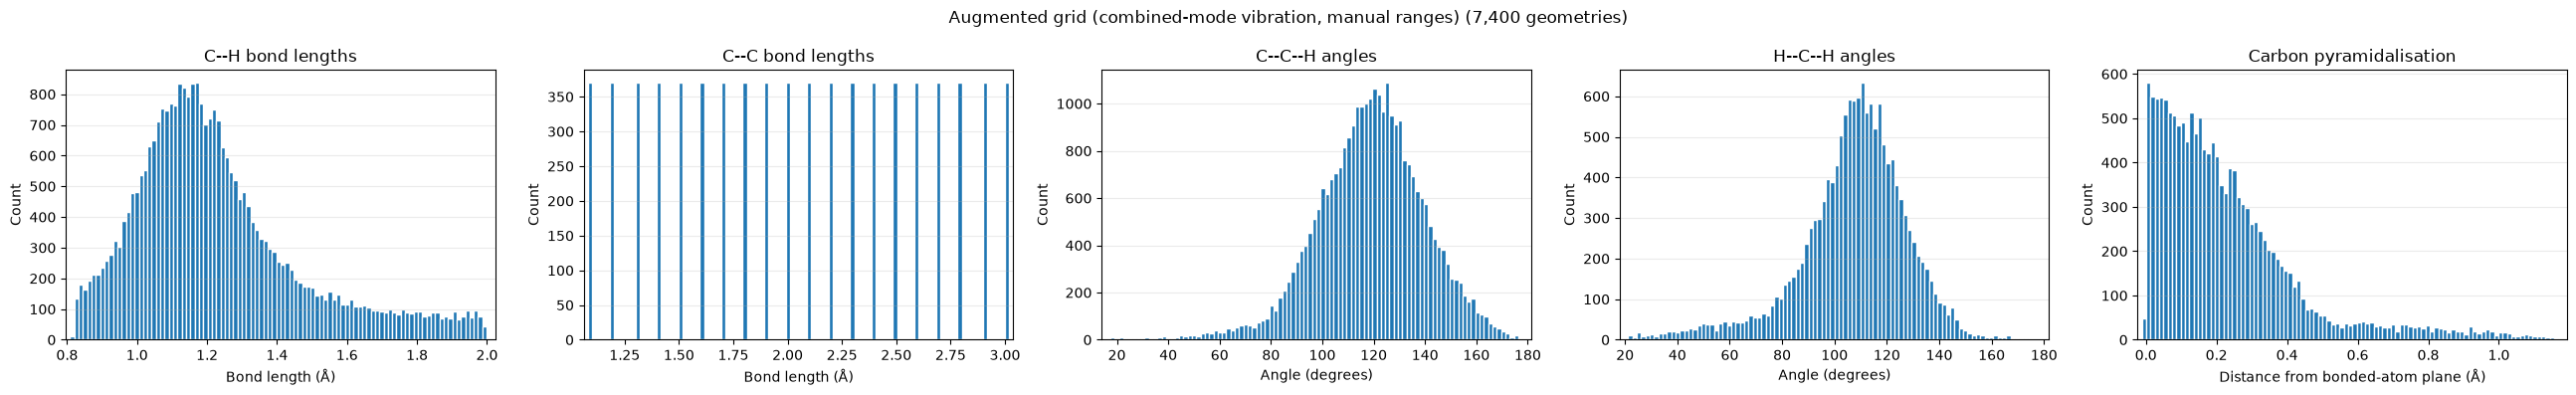

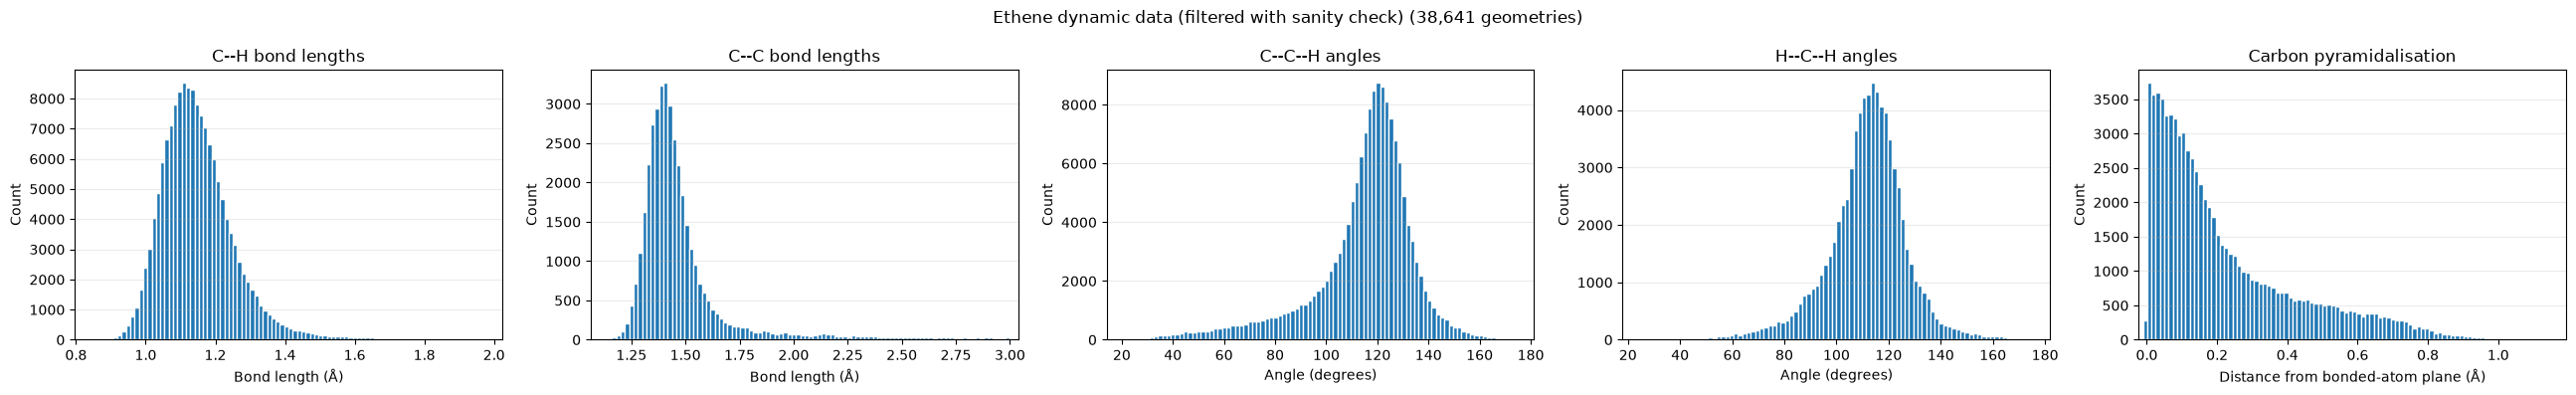

In [80]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTANT_XYZ = Path(
    "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF_combined_vibrations_mixed_ranges.xyz"
)
SANITY_FILTERED_DYNAMIC_XYZ = Path(
    "../data/A01_ethene/dynamic/A01_ethene_dynamic_CASSCF_sanity_defaults_filtered.xyz"
)

# Atom order is C, C, H, H, H, H in both extended-XYZ files.
CH_PAIRS = ((0, 2), (0, 5), (1, 3), (1, 4))
CCH_TRIPLES = ((1, 0, 2), (1, 0, 5), (0, 1, 3), (0, 1, 4))
HCH_TRIPLES = ((2, 0, 5), (3, 1, 4))
PYRAMIDALISATION_SITES = ((0, (1, 2, 5)), (1, (0, 3, 4)))


def angle_degrees(positions, atom_i, central_atom, atom_j):
    first = positions[atom_i] - positions[central_atom]
    second = positions[atom_j] - positions[central_atom]
    cosine = np.dot(first, second) / (np.linalg.norm(first) * np.linalg.norm(second))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))


def pyramidalisation(positions, carbon, plane_atoms):
    plane_origin, plane_atom1, plane_atom2 = positions[list(plane_atoms)]
    normal = np.cross(plane_atom1 - plane_origin, plane_atom2 - plane_origin)
    return float(abs(np.dot(positions[carbon] - plane_origin, normal)) / np.linalg.norm(normal))


def geometry_values(xyz_path):
    values = {
        "C--H": [], "C--C": [], "C--C--H": [], "H--C--H": [],
        "Pyramidalisation": [],
    }
    geometry_count = 0
    with xyz_path.open() as source:
        while atom_count_line := source.readline():
            atom_count = int(atom_count_line)
            source.readline()  # Extended-XYZ comment line.
            rows = [source.readline().split() for _ in range(atom_count)]
            if atom_count != 6 or [row[0] for row in rows] != ["C", "C", "H", "H", "H", "H"]:
                raise ValueError(f"Unexpected atom ordering in geometry {geometry_count} of {xyz_path}")
            positions = np.asarray([[float(value) for value in row[1:4]] for row in rows])
            values["C--C"].append(np.linalg.norm(positions[0] - positions[1]))
            values["C--H"].extend(np.linalg.norm(positions[i] - positions[j]) for i, j in CH_PAIRS)
            values["C--C--H"].extend(angle_degrees(positions, *atoms) for atoms in CCH_TRIPLES)
            values["H--C--H"].extend(angle_degrees(positions, *atoms) for atoms in HCH_TRIPLES)
            values["Pyramidalisation"].extend(
                pyramidalisation(positions, carbon, plane_atoms)
                for carbon, plane_atoms in PYRAMIDALISATION_SITES
            )
            geometry_count += 1
    if not geometry_count:
        raise ValueError(f"No geometries found in {xyz_path}")
    return geometry_count, values


PLOT_DEFINITIONS = (
    ("C--H", "C--H bond lengths", "Bond length (Å)"),
    ("C--C", "C--C bond lengths", "Bond length (Å)"),
    ("C--C--H", "C--C--H angles", "Angle (degrees)"),
    ("H--C--H", "H--C--H angles", "Angle (degrees)"),
    ("Pyramidalisation", "Carbon pyramidalisation", "Distance from bonded-atom plane (Å)"),
)


def shared_x_limits(*value_sets):
    limits = {}
    for key, _, _ in PLOT_DEFINITIONS:
        lower = min(np.min(values[key]) for values in value_sets)
        upper = max(np.max(values[key]) for values in value_sets)
        padding = 0.02 * (upper - lower) if upper > lower else max(0.01, 0.02 * abs(lower))
        limits[key] = (lower - padding, upper + padding)
    return limits


def plot_geometry_histograms(geometry_count, values, title, x_limits):
    fig, axes = plt.subplots(1, 5, figsize=(26, 4))
    for axis, (key, subplot_title, xlabel) in zip(axes, PLOT_DEFINITIONS):
        bins = np.linspace(*x_limits[key], num=101)
        axis.hist(values[key], bins=bins, color="tab:blue", edgecolor="white")
        axis.set(title=subplot_title, xlabel=xlabel, ylabel="Count", xlim=x_limits[key])
        axis.grid(axis="y", alpha=0.25)
    fig.suptitle(f"{title} ({geometry_count:,} geometries)")
    fig.tight_layout()
    plt.show()


resultant_count, resultant_values = geometry_values(RESULTANT_XYZ)
dynamic_count, dynamic_values = geometry_values(SANITY_FILTERED_DYNAMIC_XYZ)
shared_limits = shared_x_limits(resultant_values, dynamic_values)

plot_geometry_histograms(
    resultant_count, resultant_values, "Augmented grid (combined-mode vibration, manual ranges)", shared_limits
)
plot_geometry_histograms(
    dynamic_count, dynamic_values, "Ethene dynamic data (filtered with sanity check)", shared_limits
)
